# Historical Value at Risk

This notebook estimates portfolio Value at Risk using the historical simulation approach.

Historical VaR uses the empirical distribution of observed portfolio returns without imposing a parametric distribution such as the normal distribution.

The analysis covers:

1. Portfolio return distribution
2. Historical VaR at 95% confidence
3. Historical VaR at 99% confidence
4. VaR expressed as a percentage and monetary loss
5. Visualization of the loss distribution
6. Interpretation of the historical VaR estimate

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from project_01_market_risk_engine.src.data import download_prices
from project_01_market_risk_engine.src.var import historical_var, historical_expected_shortfall

In [2]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

weights = pd.Series({
    "SPY": 0.30,
    "QQQ": 0.20,
    "IWM": 0.15,
    "TLT": 0.20,
    "GLD": 0.15
})

prices = download_prices(
    tickers=TICKERS,
    start="2015-01-01",
    end="2026-01-01"
)

returns = prices.pct_change().dropna()

portfolio_returns = returns @ weights

[*********************100%***********************]  5 of 5 completed


## 1. Historical Portfolio Return Distribution

Historical simulation treats the observed portfolio returns as the empirical
distribution of potential future returns.

The historical observations are therefore not fitted to a theoretical
distribution. The observed left tail directly determines the historical VaR
estimate.

In [3]:
portfolio_returns.info()

<class 'pandas.Series'>
DatetimeIndex: 2765 entries, 2015-01-05 to 2025-12-31
Series name: None
Non-Null Count  Dtype  
--------------  -----  
2765 non-null   float64
dtypes: float64(1)
memory usage: 43.2 KB


In [4]:
portfolio_returns.describe()

count    2765.000000
mean        0.000463
std         0.008090
min        -0.068361
25%        -0.003195
50%         0.000709
75%         0.004442
max         0.074988
dtype: float64

In [7]:
portfolio_returns.sort_values(ascending=True).head()

Date
2020-03-12   -0.068361
2020-03-16   -0.065449
2020-03-18   -0.047171
2020-03-09   -0.046238
2020-03-11   -0.040769
dtype: float64

## 2. 95% Historical VaR

In [ ]:
var_95_return = portfolio_returns.quantile(0.05)
var_95_return

np.float64(-0.011847567417234497)

In [9]:
# Conventionally VaR is reported as a positve number

var_95 = -var_95_return
var_95

np.float64(0.011847567417234497)

## 3. 99% Historical VaR

In [10]:
var_99_return = portfolio_returns.quantile(0.01)
var_99_return

np.float64(-0.021801255125766576)

In [14]:
# Conventionally VaR is reported as a positve number

var_99 =-var_99_return
var_99

np.float64(0.021801255125766576)

In [15]:
var_table = pd.DataFrame({
    "Confidence Level" : ["95%", "99%"],
    "Return Quantile"  : [var_95_return, var_99_return],
    'VaR' : [var_95, var_99]
    
})

var_table

,Confidence Level,Return Quantile,VaR
0,95%,-0.011848,0.011848
1,99%,-0.021801,0.021801


## 4. Translate VaR into dollars

In [28]:
portfolio_value = 100_000
var_95_value = historical_var(portfolio_returns, confidence_level=0.95, portfolio_value= portfolio_value)
var_99_value = historical_var(portfolio_returns, confidence_level=0.99, portfolio_value= portfolio_value)

In [29]:
print(f"For a 100,000 portfolio, the estimated 1-day 95% Historical VaR: ${var_95_value:,.2f}")
print(f"For a 100,000 portfolio, the estimated 1-day 99% Historical VaR: ${var_99_value:,.2f}")

For a 100,000 portfolio, the estimated 1-day 95% Historical VaR: $1,184.76
For a 100,000 portfolio, the estimated 1-day 99% Historical VaR: $2,180.13


## 4. Visualize

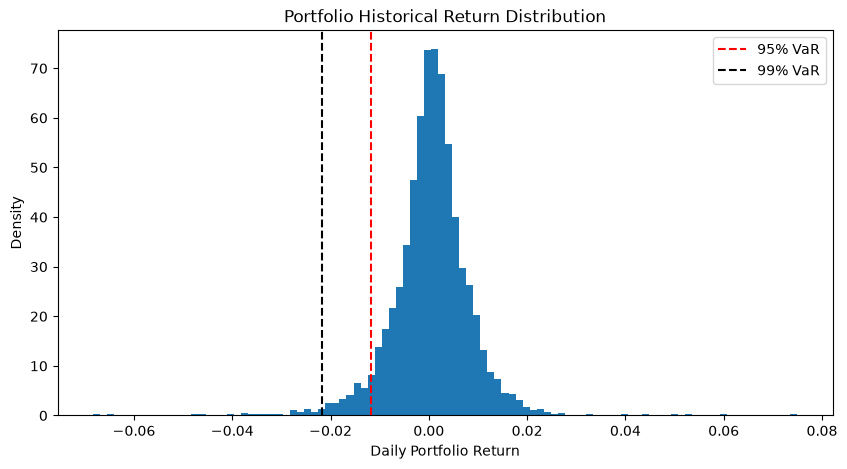

In [25]:
plt.figure(figsize=(10,5))
plt.hist(
    portfolio_returns,
    bins = 100,
    density=True
)

plt.axvline(
    var_95_return,
    color = "red",
    linestyle="--",
    label="95% VaR"
)

plt.axvline(
    var_99_return,
    color = "black",
    linestyle="--",
    label="99% VaR"
)

plt.title("Portfolio Historical Return Distribution")
plt.xlabel("Daily Portfolio Return")
plt.ylabel("Density")
plt.legend()

plt.show()

### Key Observations

The 95% one-day Historical VaR is 1.1848%, corresponding to approximately $1,184.76 for a $100,000 portfolio. 
At the 99% confidence level, Historical VaR increases to 2.1801%, corresponding to approximately $2,180.13.

With 2,765 historical observations, the 95% VaR threshold is determined by approximately the worst 5% of observations, while the 99% threshold is based on approximately the worst 1%. Consequently, the 99% estimate is more sensitive to the relatively small number of extreme observations in the historical sample.

Historical VaR makes no explicit distributional assumption and therefore retains the empirical characteristics of the observed portfolio returns.
However, it is dependent on the historical sample and provides no information about the magnitude of losses beyond the VaR threshold.

## Expected Shortfall

In [31]:
es_95 = historical_expected_shortfall(
    portfolio_returns,
    confidence_level=0.95
)

es_99 = historical_expected_shortfall(
    portfolio_returns,
    confidence_level=0.99
)

print(f"95% Historical ES: {es_95:.4%}")
print(f"99% Historical ES: {es_99:.4%}")

95% Historical ES: 1.9102%
99% Historical ES: 3.2484%


In [32]:
portfolio_value = 100_000

es_95_dollars = historical_expected_shortfall(
    portfolio_returns,
    confidence_level=0.95,
    portfolio_value=portfolio_value
)

es_99_dollars = historical_expected_shortfall(
    portfolio_returns,
    confidence_level=0.99,
    portfolio_value=portfolio_value
)

print(f"95% Historical ES: ${es_95_dollars:,.2f}")
print(f"99% Historical ES: ${es_99_dollars:,.2f}")

95% Historical ES: $1,910.24
99% Historical ES: $3,248.43


In [34]:
risk_summary = pd.DataFrame({
    "Confidence": ["95%", "99%"],
    "VaR": [var_95, var_99],
    "Expected Shortfall": [es_95, es_99]
})
risk_summary

,Confidence,VaR,Expected Shortfall
0,95%,0.011848,0.019102
1,99%,0.021801,0.032484


## VaR vs Expected Shortfall

Historical VaR identifies a percentile of the empirical loss distribution,
while Expected Shortfall measures the average loss conditional on returns
falling beyond the VaR threshold.

Expected Shortfall therefore provides information about the severity of losses
in the tail that VaR does not capture.

For a coherent loss distribution, Expected Shortfall should be at least as
large as VaR at the same confidence level.